In [1]:
# ============================================================
# NOTEBOOK 3 — BASELINE MODELS
# Model 1: 1D-CNN
# Model 2: BiLSTM
# Both are deep learning baselines
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
import os, time

# Verify GPU
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")

# Load preprocessed data
save_dir = '/content/drive/MyDrive/DL_Project_Gait/data/processed'

print("\nLoading preprocessed windows...")
X_train = np.load(f'{save_dir}/X_train.npy')
y_train = np.load(f'{save_dir}/y_train.npy')
X_val   = np.load(f'{save_dir}/X_val.npy')
y_val   = np.load(f'{save_dir}/y_val.npy')
X_test  = np.load(f'{save_dir}/X_test.npy')
y_test  = np.load(f'{save_dir}/y_test.npy')
class_weights = np.load(f'{save_dir}/class_weights.npy')

print(f"✓ X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"✓ X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"✓ X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Constants
N_CLASSES  = 10
N_FEATURES = 36
SEQ_LEN    = 128
BATCH_SIZE = 64
N_EPOCHS   = 40

# Activity names for plots
activity_names = [
    'walking', 'running', 'going_up', 'going_down', 'sitting',
    'sitting_down', 'standing_up', 'standing', 'up_elevator', 'down_elevator'
]

print(f"\n✓ Ready. N_CLASSES={N_CLASSES}, N_FEATURES={N_FEATURES}, SEQ_LEN={SEQ_LEN}")

Mounted at /content/drive
PyTorch version: 2.10.0+cu128
CUDA available: True
Device: Tesla T4

Using device: cuda

Loading preprocessed windows...
✓ X_train: (10274, 128, 36)  y_train: (10274,)
✓ X_val:   (2896, 128, 36)    y_val:   (2896,)
✓ X_test:  (4607, 128, 36)   y_test:  (4607,)

✓ Ready. N_CLASSES=10, N_FEATURES=36, SEQ_LEN=128


In [2]:
# ============================================================
# CREATE PYTORCH DATASETS AND DATALOADERS
# ============================================================

# Convert numpy arrays to PyTorch tensors
# CNN expects: (batch, channels, time) → transpose last two dims
# LSTM expects: (batch, time, features) → keep as is

# For CNN: X shape = (N, 36, 128)
X_train_cnn = torch.FloatTensor(X_train).permute(0, 2, 1)  # (N, 36, 128)
X_val_cnn   = torch.FloatTensor(X_val).permute(0, 2, 1)
X_test_cnn  = torch.FloatTensor(X_test).permute(0, 2, 1)

# For LSTM: X shape = (N, 128, 36)
X_train_lstm = torch.FloatTensor(X_train)  # (N, 128, 36)
X_val_lstm   = torch.FloatTensor(X_val)
X_test_lstm  = torch.FloatTensor(X_test)

# Labels
y_train_t = torch.LongTensor(y_train)
y_val_t   = torch.LongTensor(y_val)
y_test_t  = torch.LongTensor(y_test)

# DataLoaders for CNN
train_loader_cnn = DataLoader(TensorDataset(X_train_cnn, y_train_t),
                               batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn   = DataLoader(TensorDataset(X_val_cnn, y_val_t),
                               batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn  = DataLoader(TensorDataset(X_test_cnn, y_test_t),
                               batch_size=BATCH_SIZE, shuffle=False)

# DataLoaders for LSTM
train_loader_lstm = DataLoader(TensorDataset(X_train_lstm, y_train_t),
                                batch_size=BATCH_SIZE, shuffle=True)
val_loader_lstm   = DataLoader(TensorDataset(X_val_lstm, y_val_t),
                                batch_size=BATCH_SIZE, shuffle=False)
test_loader_lstm  = DataLoader(TensorDataset(X_test_lstm, y_test_t),
                                batch_size=BATCH_SIZE, shuffle=False)

# Class weights tensor for loss function
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print("DataLoaders created:")
print(f"  CNN input shape:  {next(iter(train_loader_cnn))[0].shape}")
print(f"  LSTM input shape: {next(iter(train_loader_lstm))[0].shape}")
print(f"  Train batches: {len(train_loader_cnn)}")
print(f"  Val batches:   {len(val_loader_cnn)}")
print(f"  Test batches:  {len(test_loader_cnn)}")
print(f"\n✓ DataLoaders ready!")

DataLoaders created:
  CNN input shape:  torch.Size([64, 36, 128])
  LSTM input shape: torch.Size([64, 128, 36])
  Train batches: 161
  Val batches:   46
  Test batches:  72

✓ DataLoaders ready!


In [3]:
# ============================================================
# TRAINING AND EVALUATION UTILITIES
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / len(loader), correct / total


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, model_name, n_epochs=N_EPOCHS):
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': []}
    best_val_acc = 0
    best_model_path = f'/content/drive/MyDrive/DL_Project_Gait/models/{model_name}_best.pth'

    print(f"\nTraining {model_name}...")
    print("-" * 60)

    for epoch in range(n_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc     = evaluate(model, val_loader)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{n_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
                  + (" ← best" if val_acc == best_val_acc else ""))

    print(f"\n✓ Best val accuracy: {best_val_acc:.4f}")
    print(f"✓ Model saved to {best_model_path}")
    return history, best_model_path


def plot_training_curves(histories, model_names, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['blue', 'red', 'green']

    for i, (history, name) in enumerate(zip(histories, model_names)):
        c = colors[i % len(colors)]
        axes[0].plot(history['train_loss'], '--', color=c, alpha=0.5, label=f'{name} train')
        axes[0].plot(history['val_loss'],   '-',  color=c,            label=f'{name} val')
        axes[1].plot(history['train_acc'],  '--', color=c, alpha=0.5, label=f'{name} train')
        axes[1].plot(history['val_acc'],    '-',  color=c,            label=f'{name} val')

    axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title('Accuracy Curves', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Loss curves saved!")


def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(N_CLASSES))
    ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(activity_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(activity_names, fontsize=9)

    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, f'{cm_pct[i,j]:.1f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_pct[i,j] > 50 else 'black')

    ax.set_title(f'Confusion Matrix — {model_name} (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Confusion matrix saved!")


def print_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Metrics")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"{'='*50}")
    return {'model': model_name, 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1': f1}

print("✓ All training utilities defined!")

✓ All training utilities defined!


In [4]:
# ============================================================
# MODEL 1: 1D-CNN (Deep Learning Baseline)
# Architecture: 3 Conv blocks + Global Average Pooling + FC
# ============================================================

class CNN1D(nn.Module):
    def __init__(self, n_channels=N_FEATURES, n_classes=N_CLASSES):
        super(CNN1D, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):          # x: (batch, channels, time)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)            # (batch, 256, 1)
        x = self.classifier(x)    # (batch, n_classes)
        return x

# Instantiate and check
cnn_model = CNN1D().to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"1D-CNN Architecture:")
print(cnn_model)
print(f"\nTotal parameters: {total_params:,}")

# Quick forward pass test
dummy = torch.randn(4, N_FEATURES, SEQ_LEN).to(DEVICE)
out = cnn_model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  (should be [4, 10])")

1D-CNN Architecture:
CNN1D(
  (block1): Sequential(
    (0): Conv1d(36, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (block3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (gap): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear

In [5]:
# Train 1D-CNN
cnn_model = CNN1D().to(DEVICE)
cnn_history, cnn_model_path = train_model(
    cnn_model, train_loader_cnn, val_loader_cnn,
    model_name='CNN1D', n_epochs=N_EPOCHS
)


Training CNN1D...
------------------------------------------------------------
  Epoch   5/40 | Train Loss: 0.4049 Acc: 0.7796 | Val Loss: 0.3439 Acc: 0.7887 ← best
  Epoch  10/40 | Train Loss: 0.3713 Acc: 0.7906 | Val Loss: 0.3235 Acc: 0.8232 ← best
  Epoch  15/40 | Train Loss: 0.3522 Acc: 0.8015 | Val Loss: 0.3537 Acc: 0.8249
  Epoch  20/40 | Train Loss: 0.3262 Acc: 0.8202 | Val Loss: 0.4778 Acc: 0.8263
  Epoch  25/40 | Train Loss: 0.3086 Acc: 0.8295 | Val Loss: 0.5092 Acc: 0.8602 ← best
  Epoch  30/40 | Train Loss: 0.2962 Acc: 0.8392 | Val Loss: 0.5155 Acc: 0.8222
  Epoch  35/40 | Train Loss: 0.2805 Acc: 0.8453 | Val Loss: 0.6495 Acc: 0.8522
  Epoch  40/40 | Train Loss: 0.2796 Acc: 0.8462 | Val Loss: 0.6369 Acc: 0.8560

✓ Best val accuracy: 0.8626
✓ Model saved to /content/drive/MyDrive/DL_Project_Gait/models/CNN1D_best.pth



  1D-CNN — Test Metrics
  Accuracy:  0.8046 (80.46%)
  Precision: 0.7889
  Recall:    0.8046
  F1 Score:  0.7596


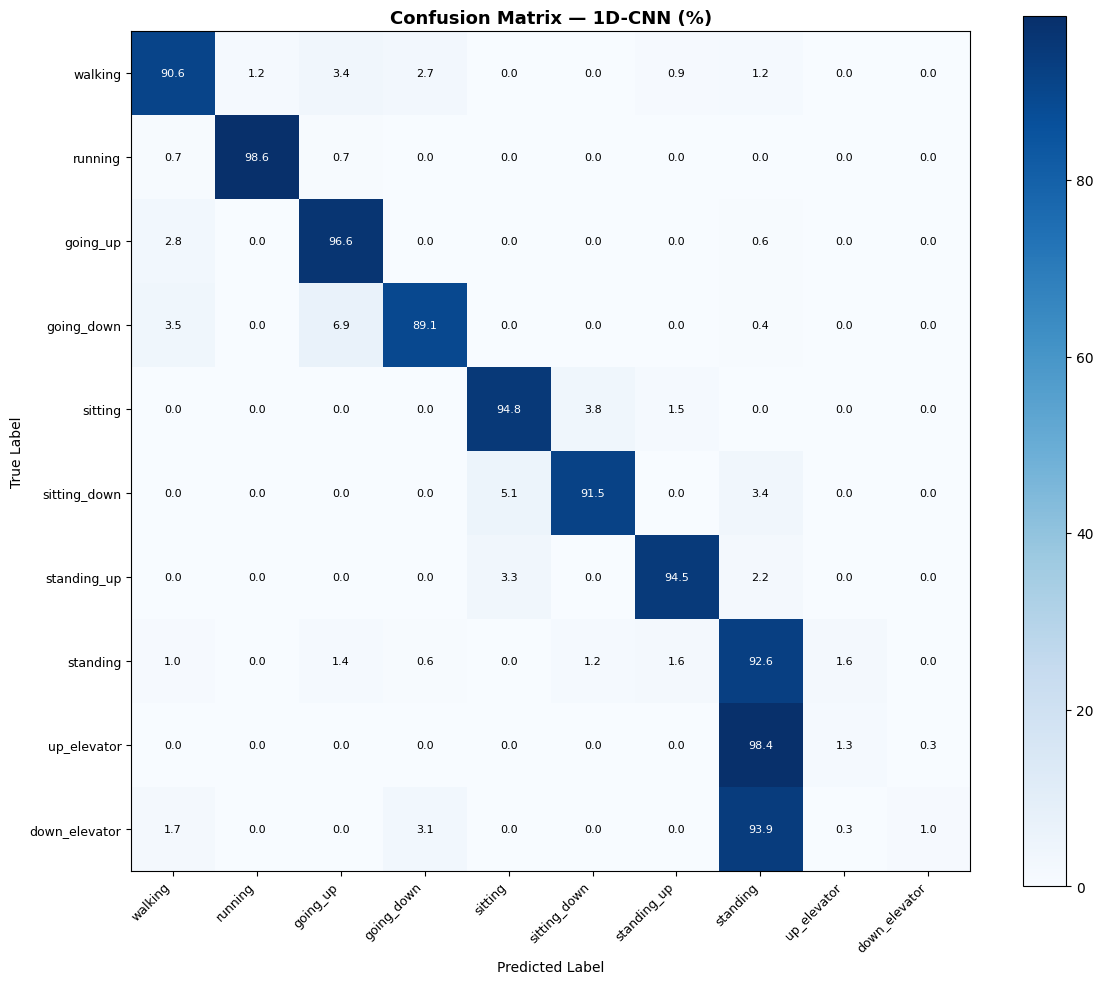

✓ Confusion matrix saved!


In [6]:
# Load best CNN model and evaluate on test set
cnn_model.load_state_dict(torch.load(cnn_model_path))
cnn_preds, cnn_labels = get_predictions(cnn_model, test_loader_cnn)

# Print metrics
cnn_metrics = print_metrics(cnn_labels, cnn_preds, "1D-CNN")

# Confusion matrix
plot_confusion_matrix(cnn_labels, cnn_preds, "1D-CNN",
    '/content/drive/MyDrive/DL_Project_Gait/results/confusion_matrix_cnn.png')

In [7]:
# ============================================================
# MODEL 2: BiLSTM (Deep Learning Baseline)
# Architecture: 2-layer Bidirectional LSTM + FC classifier
# ============================================================

class BiLSTM(nn.Module):
    def __init__(self, n_features=N_FEATURES, n_classes=N_CLASSES,
                 hidden_size=128, num_layers=2):
        super(BiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),  # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):           # x: (batch, time, features)
        out, _ = self.lstm(x)       # out: (batch, time, hidden*2)
        out = out[:, -1, :]         # take last timestep: (batch, hidden*2)
        out = self.classifier(out)  # (batch, n_classes)
        return out

# Check architecture
lstm_model = BiLSTM().to(DEVICE)
total_params = sum(p.numel() for p in lstm_model.parameters())
print("BiLSTM Architecture:")
print(lstm_model)
print(f"\nTotal parameters: {total_params:,}")

# Quick forward pass test
dummy = torch.randn(4, SEQ_LEN, N_FEATURES).to(DEVICE)
out = lstm_model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  (should be [4, 10])")

BiLSTM Architecture:
BiLSTM(
  (lstm): LSTM(36, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 599,434
Input shape:  torch.Size([4, 128, 36])
Output shape: torch.Size([4, 10])  (should be [4, 10])


In [8]:
# Train BiLSTM
lstm_model = BiLSTM().to(DEVICE)
lstm_history, lstm_model_path = train_model(
    lstm_model, train_loader_lstm, val_loader_lstm,
    model_name='BiLSTM', n_epochs=N_EPOCHS
)


Training BiLSTM...
------------------------------------------------------------
  Epoch   5/40 | Train Loss: 0.5258 Acc: 0.6991 | Val Loss: 0.5075 Acc: 0.6979
  Epoch  10/40 | Train Loss: 0.4819 Acc: 0.7182 | Val Loss: 0.3995 Acc: 0.7341
  Epoch  15/40 | Train Loss: 0.4490 Acc: 0.7397 | Val Loss: 0.3639 Acc: 0.7503 ← best
  Epoch  20/40 | Train Loss: 0.4141 Acc: 0.7564 | Val Loss: 0.3708 Acc: 0.7638
  Epoch  25/40 | Train Loss: 0.4235 Acc: 0.7531 | Val Loss: 0.3923 Acc: 0.7524
  Epoch  30/40 | Train Loss: 0.3701 Acc: 0.7840 | Val Loss: 0.3521 Acc: 0.8028
  Epoch  35/40 | Train Loss: 0.3401 Acc: 0.8006 | Val Loss: 0.3548 Acc: 0.8063
  Epoch  40/40 | Train Loss: 0.3317 Acc: 0.8074 | Val Loss: 0.3501 Acc: 0.8163

✓ Best val accuracy: 0.8166
✓ Model saved to /content/drive/MyDrive/DL_Project_Gait/models/BiLSTM_best.pth



  BiLSTM — Test Metrics
  Accuracy:  0.7936 (79.36%)
  Precision: 0.7868
  Recall:    0.7936
  F1 Score:  0.7866


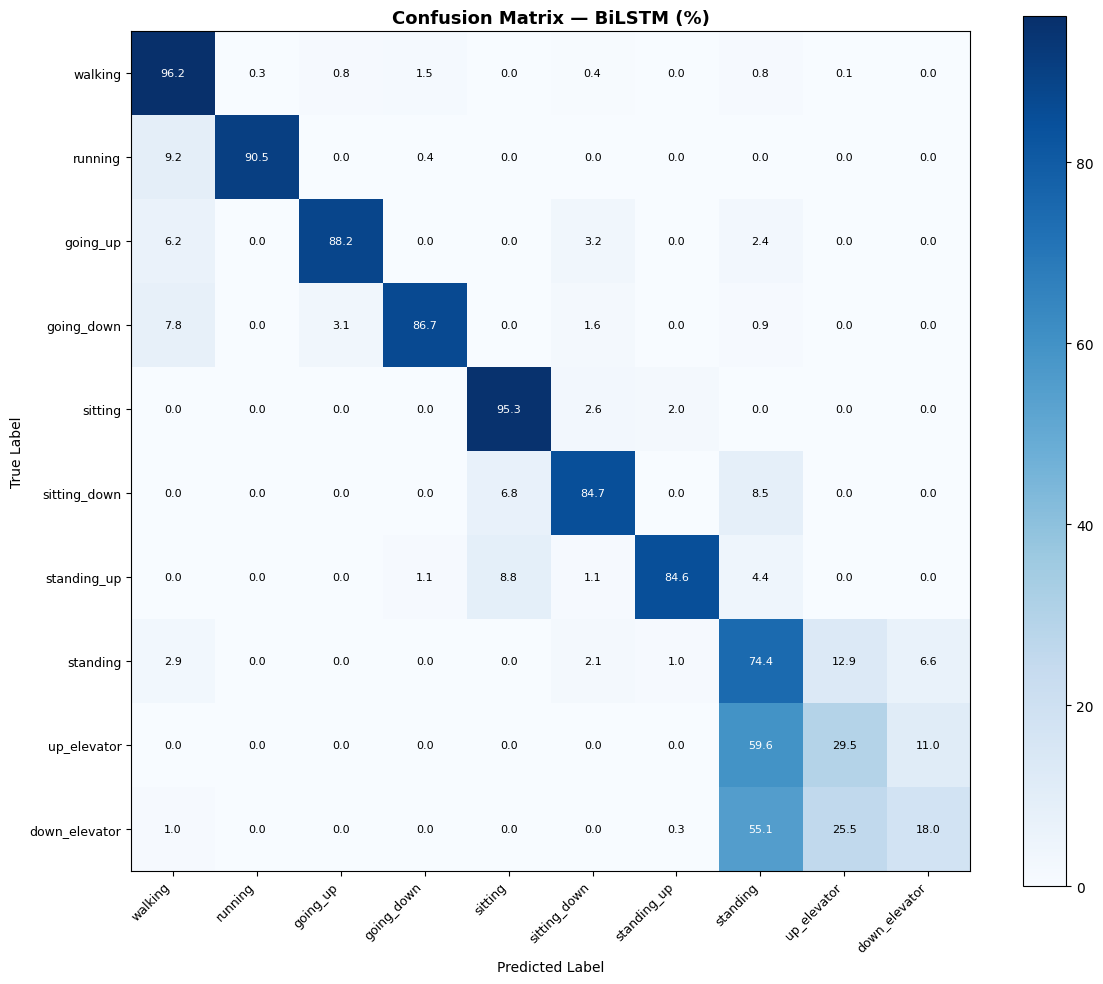

✓ Confusion matrix saved!


In [9]:
# Load best BiLSTM and evaluate
lstm_model.load_state_dict(torch.load(lstm_model_path))
lstm_preds, lstm_labels = get_predictions(lstm_model, test_loader_lstm)

# Metrics
lstm_metrics = print_metrics(lstm_labels, lstm_preds, "BiLSTM")

# Confusion matrix
plot_confusion_matrix(lstm_labels, lstm_preds, "BiLSTM",
    '/content/drive/MyDrive/DL_Project_Gait/results/confusion_matrix_bilstm.png')

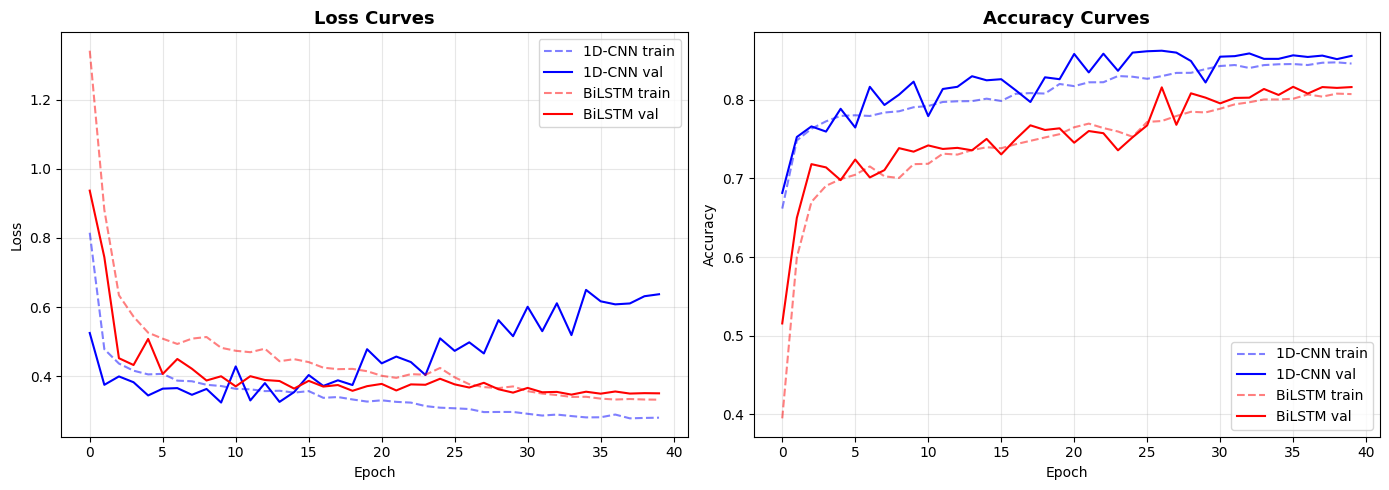

✓ Loss curves saved!

  BASELINE MODELS — COMPARISON TABLE
  Model          Accuracy  Precision     Recall         F1
------------------------------------------------------------
  1D-CNN           0.8046     0.7889     0.8046     0.7596
  BiLSTM           0.7936     0.7868     0.7936     0.7866


In [10]:
# Plot CNN and BiLSTM training curves on same graph
plot_training_curves(
    histories=[cnn_history, lstm_history],
    model_names=['1D-CNN', 'BiLSTM'],
    save_path='/content/drive/MyDrive/DL_Project_Gait/results/loss_curves_baselines.png'
)

# Side by side comparison table
print("\n" + "="*60)
print("  BASELINE MODELS — COMPARISON TABLE")
print("="*60)
print(f"  {'Model':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*60)
for m in [cnn_metrics, lstm_metrics]:
    print(f"  {m['model']:<12} {m['accuracy']:>10.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>10.4f} {m['f1']:>10.4f}")
print("="*60)